# MIMO IHDP Lateral Turn on the Nonlinear B-737

This notebook demonstrates a **single MIMO IHDP agent** in the lateral-directional control path of the nonlinear Boeing 737 model. The plant is always created through Gymnasium:

```python
env = gym.make("NonlinearB737-v0", ...)
```

The turn task is:

* start from trimmed level cruise at FL200 and 650 ft/s;
* hold the initial heading and altitude for 20 seconds;
* command a 90 deg right turn at 0.6 deg/s, so the commanded signal is stretched over the 200 second simulation;
* stabilize altitude and airspeed during the maneuver with elevator and engine throttle;
* keep the turn coordinated: small sideslip, bounded bank, stable yaw rate.

The IHDP part is one actor with two outputs:

```text
state  = [phi, p, beta, r]
action = [d_aileron_residual, d_rudder_residual]
```

The transparent coordinated-turn law supplies a safe nominal command and the reference trajectory. The **single MIMO IHDP** learns an online residual around that command and is added directly to the lateral actuators:

```text
delta_a = delta_a_nominal + IHDP[0]
delta_r = delta_r_nominal + IHDP[1]
```

Elevator and engine throttle use a longitudinal altitude/airspeed hold law so the lateral example remains readable and the aircraft does not leave the cruise envelope during the turn.


## 1. Imports


In [1]:
import math
import warnings

warnings.filterwarnings("ignore", message="CUDA initialization.*")
warnings.filterwarnings("ignore")

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

import tensoraerospace  # noqa: F401  -- registers Gymnasium envs
from tensoraerospace.aerospacemodel.b737.nonlinear import (
    B737Configuration,
    trim,
)
from tensoraerospace.agent.ihdp.model import IHDPAgent
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period


## 2. Trim point and scenario


In [2]:
ALTITUDE_FT = 20_000.0
AIRSPEED_FT_S = 650.0
CONFIG = B737Configuration.B737_800

trim_result = trim(
    altitude_ft=ALTITUDE_FT,
    V_ft_s=AIRSPEED_FT_S,
    config=CONFIG,
)
assert trim_result.converged, f"trim failed: residual={trim_result.residual:.2e}"

theta_trim_rad = float(trim_result.alpha_rad)
delta_e_trim_deg = math.degrees(trim_result.elevator_rad)
throttle_trim = float(trim_result.throttle)

dt = 0.02
tp = generate_time_period(tn=200.0, dt=dt)
tps = convert_tp_to_sec_tp(tp, dt=dt)
number_time_steps = len(tp)

TURN_START_SEC = 20.0
TURN_RATE_DEG_S = 0.6
TARGET_HEADING_DEG = 90.0

ALTITUDE_INTEGRAL_LIMIT = 700.0
ALTITUDE_INTEGRAL_LEAK = 0.9987
THETA_ALTITUDE_GAIN = 1.60e-4
THETA_ALTITUDE_RATE_GAIN = 5.20e-3
THETA_ALTITUDE_INTEGRAL_GAIN = 2.00e-5
THROTTLE_SPEED_GAIN = 0.007
THROTTLE_ALTITUDE_GAIN = 3.50e-4
THROTTLE_ALTITUDE_RATE_GAIN = 3.50e-3
THROTTLE_ALTITUDE_INTEGRAL_GAIN = 1.00e-5
THROTTLE_RATE_LIMIT = 0.12

print(f"trim @ FL{ALTITUDE_FT/100:.0f}, V={AIRSPEED_FT_S:.0f} ft/s, {CONFIG.value}:")
print(f"  theta_trim   = {math.degrees(theta_trim_rad):+.3f} deg")
print(f"  delta_e_trim = {delta_e_trim_deg:+.3f} deg")
print(f"  throttle     = {throttle_trim:.4f}")
print(f"  residual     = {trim_result.residual:.2e}")
print(f"scenario      = hold 20 s, then 90 deg right turn at {TURN_RATE_DEG_S:.1f} deg/s")


trim @ FL200, V=650 ft/s, 737-800:
  theta_trim   = +2.012 deg
  delta_e_trim = -1.175 deg
  throttle     = 0.4769
  residual     = 3.97e-14
scenario      = hold 20 s, then 90 deg right turn at 0.6 deg/s


## 3. Utility functions


In [3]:
def wrap_to_pi(angle_rad: float) -> float:
    return (angle_rad + math.pi) % (2.0 * math.pi) - math.pi


def saturate(value: float, low: float, high: float) -> float:
    return min(high, max(low, value))


def rate_limit(previous: float, command: float, max_rate: float, dt: float) -> float:
    return previous + saturate(command - previous, -max_rate * dt, max_rate * dt)


## 4. Build one MIMO IHDP lateral controller


In [4]:
random_seed = 47
np.random.seed(random_seed)
torch.manual_seed(random_seed)

actor_settings = {
    "start_training": 5,
    "layers": (32, 2),              # two actor outputs: [aileron, rudder]
    "activations": ("tanh", "tanh"),
    "learning_rate": 0.4,
    "learning_rate_exponent_limit": 10,
    "type_PE": "combined",
    "amplitude_3211": [0.01, 0.005],
    "pulse_length_3211": 6.0 / dt,
    "maximum_input": [0.4, 0.2],    # deg residual limits
    "maximum_q_rate": 20,
    "WB_limits": 20,
    "NN_initial": random_seed,
    "cascade_actor": False,
    "learning_rate_cascaded": 1.0,
}

critic_settings = {
    "Q_weights": [1200, 5, 4000, 40],
    "start_training": -1,
    "gamma": 0.99,
    "learning_rate": 2.0,
    "learning_rate_exponent_limit": 10,
    "layers": (32, 1),
    "activations": ("tanh", "linear"),
    "WB_limits": 20,
    "NN_initial": random_seed,
    "indices_tracking_states": [0, 1, 2, 3],
}

incremental_settings = {
    "number_time_steps": number_time_steps,
    "dt": dt,
    "input_magnitude_limits": [0.4, 0.2],
    "input_rate_limits": [4.0, 2.0],
}

lateral_ihdp = IHDPAgent(
    actor_settings,
    critic_settings,
    incremental_settings,
    tracking_states=["phi", "p", "beta", "r"],
    selected_states=["phi", "p", "beta", "r"],
    selected_input=["d_aileron_residual", "d_rudder_residual"],
    number_time_steps=number_time_steps,
    indices_tracking_states=[0, 1, 2, 3],
)

print("MIMO IHDP actor output channels:", lateral_ihdp.selected_input)
print("actor final layer size:", actor_settings["layers"][-1])


MIMO IHDP actor output channels: ['d_aileron_residual', 'd_rudder_residual']
actor final layer size: 2


## 5. Create the B-737 Gymnasium environment


In [5]:
env = gym.make(
    "NonlinearB737-v0",
    trim_at=(ALTITUDE_FT, AIRSPEED_FT_S),
    number_time_steps=number_time_steps,
    dt=dt,
    integrator="rk4",
    action_space="virtual",
    config=CONFIG,
)

obs, _ = env.reset(seed=random_seed)
print("gym env wrapper: ", type(env).__name__)
print("unwrapped env:   ", type(env.unwrapped).__name__)
print("action_space:    ", env.action_space)


gym env wrapper:  OrderEnforcing
unwrapped env:    NonlinearB737Env
action_space:     Box([-0.30019663 -0.35081118 -0.35081118  0.        ], [0.30019663 0.35081118 0.35081118 1.        ], (4,), float64)


## 6. Online rollout


In [6]:
reference_signal = np.zeros((4, number_time_steps))
obs, _ = env.reset(seed=random_seed)

last_altitude = -float(obs[11])
altitude_integral = 0.0

delta_e_deg = delta_e_trim_deg
delta_a_deg = 0.0
delta_r_deg = 0.0
throttle = throttle_trim

log = {
    "t": [],
    "psi": [],
    "psi_ref": [],
    "psi_error": [],
    "phi": [],
    "phi_cmd": [],
    "beta": [],
    "r": [],
    "r_cmd": [],
    "altitude": [],
    "altitude_rate": [],
    "altitude_integral": [],
    "speed": [],
    "theta": [],
    "theta_cmd": [],
    "delta_e": [],
    "delta_a_nom": [],
    "delta_r_nom": [],
    "delta_a": [],
    "delta_r": [],
    "throttle": [],
    "ihdp_aileron": [],
    "ihdp_rudder": [],
    "x_e": [],
    "y_e": [],
}

for step in tqdm(range(number_time_steps - 3)):
    t = step * dt

    u_b, v_b, w_b = obs[:3]
    p, q, r = obs[3:6]
    phi, theta, psi = obs[6:9]
    x_e, y_e, z_e = obs[9:12]

    speed = float(np.linalg.norm(obs[:3]))
    altitude = -float(z_e)
    beta = math.asin(np.clip(v_b / max(speed, 1.0), -1.0, 1.0))
    altitude_rate = (altitude - last_altitude) / dt if step > 0 else 0.0
    last_altitude = altitude

    if t < TURN_START_SEC:
        psi_ref_deg = 0.0
        psi_ref_rate_rad_s = 0.0
    else:
        psi_ref_deg = min(TARGET_HEADING_DEG, (t - TURN_START_SEC) * TURN_RATE_DEG_S)
        psi_ref_rate_rad_s = (
            math.radians(TURN_RATE_DEG_S)
            if psi_ref_deg < TARGET_HEADING_DEG
            else 0.0
        )

    psi_ref_rad = math.radians(psi_ref_deg)
    psi_error_rad = wrap_to_pi(psi_ref_rad - psi)

    phi_ff = (
        math.atan2(AIRSPEED_FT_S * psi_ref_rate_rad_s, 32.174)
        if psi_ref_rate_rad_s
        else 0.0
    )
    phi_cmd = saturate(
        phi_ff + 1.15 * psi_error_rad,
        math.radians(-25.0),
        math.radians(25.0),
    )
    r_cmd = 32.174 * math.tan(phi_cmd) / max(speed, 100.0)

    altitude_error = ALTITUDE_FT - altitude
    altitude_integral = saturate(
        ALTITUDE_INTEGRAL_LEAK * altitude_integral + altitude_error * dt,
        -ALTITUDE_INTEGRAL_LIMIT,
        ALTITUDE_INTEGRAL_LIMIT,
    )
    theta_bank_comp = math.radians(10.0) * (1.0 / max(math.cos(phi_cmd), 0.3) - 1.0)
    theta_cmd = saturate(
        theta_trim_rad
        + theta_bank_comp
        + THETA_ALTITUDE_GAIN * altitude_error
        - THETA_ALTITUDE_RATE_GAIN * altitude_rate
        + THETA_ALTITUDE_INTEGRAL_GAIN * altitude_integral,
        theta_trim_rad + math.radians(-2.0),
        theta_trim_rad + math.radians(6.0),
    )

    # Nominal coordinated-turn command. The MIMO IHDP residual is added
    # directly to the lateral surfaces below.
    delta_e_nom = (
        delta_e_trim_deg
        - 1.75 * math.degrees(theta_cmd - theta)
        + 1.65 * math.degrees(q)
    )
    delta_a_nom = 0.30 * math.degrees(phi_cmd - phi) - 0.20 * math.degrees(p)
    delta_r_nom = -1.3 * math.degrees(beta) - 0.25 * math.degrees(r_cmd - r)
    throttle_nom = (
        throttle_trim
        + THROTTLE_SPEED_GAIN * (AIRSPEED_FT_S - speed)
        + THROTTLE_ALTITUDE_GAIN * altitude_error
        + THROTTLE_ALTITUDE_INTEGRAL_GAIN * altitude_integral
        - THROTTLE_ALTITUDE_RATE_GAIN * altitude_rate
    )

    for ref_index in (step, step + 1):
        if ref_index < number_time_steps:
            reference_signal[:, ref_index] = [phi_cmd, 0.0, 0.0, r_cmd]

    xt_lateral = np.array([[phi], [p], [beta], [r]], dtype=np.float64)
    ihdp_action = lateral_ihdp.predict(xt_lateral, reference_signal, step)
    ihdp_aileron_deg, ihdp_rudder_deg = np.asarray(ihdp_action).flatten()

    delta_e_deg = rate_limit(delta_e_deg, saturate(delta_e_nom, -10.0, 8.0), 20.0, dt)
    delta_a_deg = rate_limit(delta_a_deg, saturate(delta_a_nom + ihdp_aileron_deg, -12.0, 12.0), 25.0, dt)
    delta_r_deg = rate_limit(delta_r_deg, saturate(delta_r_nom + ihdp_rudder_deg, -10.0, 10.0), 20.0, dt)
    throttle = rate_limit(throttle, saturate(throttle_nom, 0.25, 0.9), THROTTLE_RATE_LIMIT, dt)

    action = np.array([
        math.radians(delta_e_deg),
        math.radians(delta_a_deg),
        math.radians(delta_r_deg),
        throttle,
    ], dtype=np.float64)

    obs, _reward, terminated, truncated, _info = env.step(action)

    log["t"].append(t)
    log["psi"].append(math.degrees(psi))
    log["psi_ref"].append(psi_ref_deg)
    log["psi_error"].append(math.degrees(psi_error_rad))
    log["phi"].append(math.degrees(phi))
    log["phi_cmd"].append(math.degrees(phi_cmd))
    log["beta"].append(math.degrees(beta))
    log["r"].append(math.degrees(r))
    log["r_cmd"].append(math.degrees(r_cmd))
    log["altitude"].append(altitude)
    log["altitude_rate"].append(altitude_rate)
    log["altitude_integral"].append(altitude_integral)
    log["speed"].append(speed)
    log["theta"].append(math.degrees(theta))
    log["theta_cmd"].append(math.degrees(theta_cmd))
    log["delta_e"].append(delta_e_deg)
    log["delta_a_nom"].append(delta_a_nom)
    log["delta_r_nom"].append(delta_r_nom)
    log["delta_a"].append(delta_a_deg)
    log["delta_r"].append(delta_r_deg)
    log["throttle"].append(throttle)
    log["ihdp_aileron"].append(float(ihdp_aileron_deg))
    log["ihdp_rudder"].append(float(ihdp_rudder_deg))
    log["x_e"].append(float(x_e))
    log["y_e"].append(float(y_e))

    if terminated or truncated:
        break

for key, value in log.items():
    log[key] = np.asarray(value, dtype=float)


  0%|          | 0/9998 [00:00<?, ?it/s]

  1%|          | 100/9998 [00:00<00:09, 995.75it/s]

  2%|▏         | 201/9998 [00:00<00:09, 1000.70it/s]

  3%|▎         | 305/9998 [00:00<00:09, 1014.14it/s]

  4%|▍         | 407/9998 [00:00<00:09, 1004.56it/s]

...

 97%|█████████▋| 9680/9998 [00:09<00:00, 990.43it/s]

 98%|█████████▊| 9782/9998 [00:09<00:00, 998.32it/s]

 99%|█████████▉| 9883/9998 [00:10<00:00, 1000.91it/s]

100%|█████████▉| 9986/9998 [00:10<00:00, 1008.30it/s]

100%|██████████| 9998/9998 [00:10<00:00, 981.46it/s] 

## 7. Turn response plots


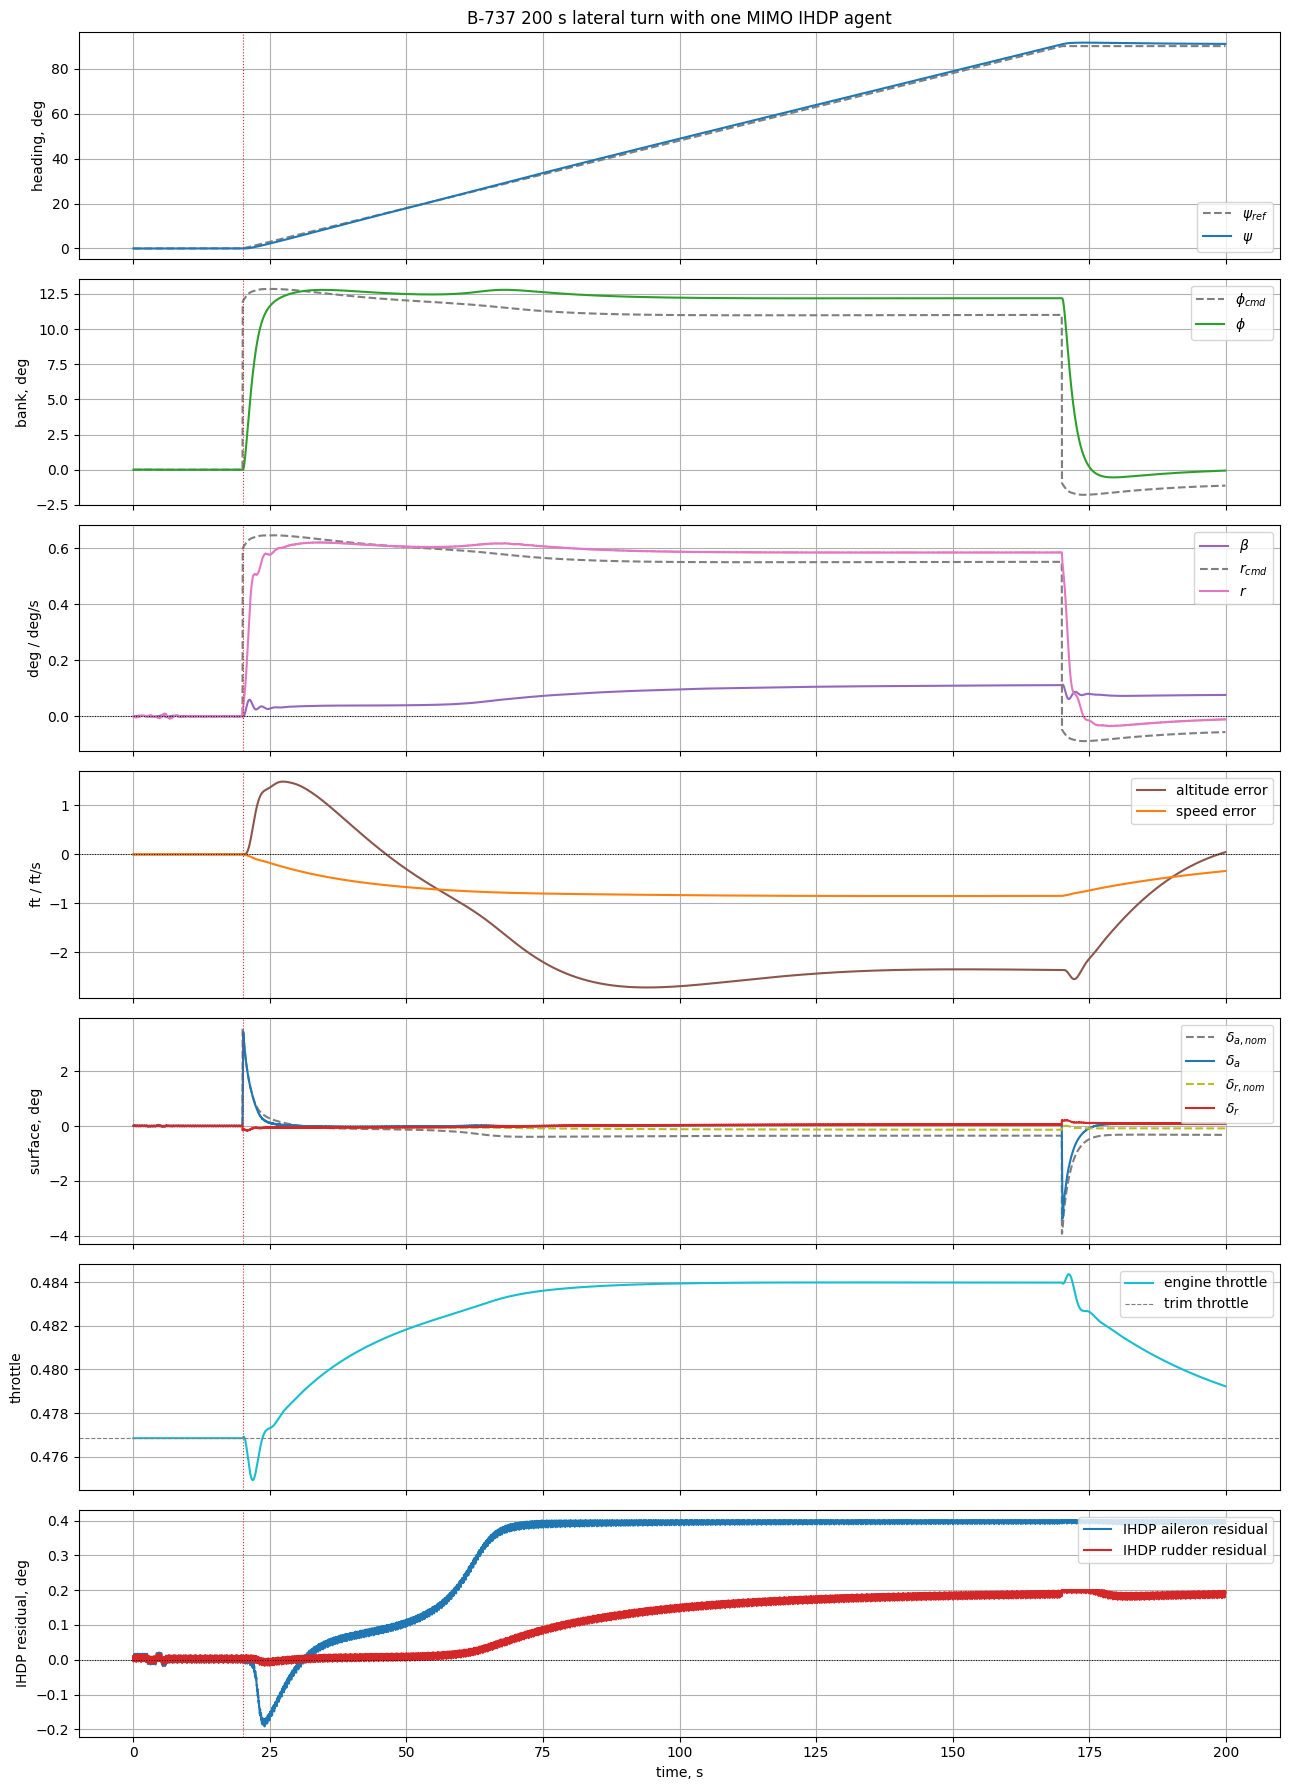

In [7]:
fig, axes = plt.subplots(7, 1, figsize=(13, 18), sharex=True)

axes[0].plot(log["t"], log["psi_ref"], "--", color="tab:gray", label=r"$\psi_{ref}$")
axes[0].plot(log["t"], log["psi"], color="tab:blue", label=r"$\psi$")
axes[0].set_ylabel("heading, deg")
axes[0].set_title("B-737 200 s lateral turn with one MIMO IHDP agent")
axes[0].grid(True)
axes[0].legend(loc="lower right")

axes[1].plot(log["t"], log["phi_cmd"], "--", color="tab:gray", label=r"$\phi_{cmd}$")
axes[1].plot(log["t"], log["phi"], color="tab:green", label=r"$\phi$")
axes[1].set_ylabel("bank, deg")
axes[1].grid(True)
axes[1].legend(loc="upper right")

axes[2].plot(log["t"], log["beta"], color="tab:purple", label=r"$\beta$")
axes[2].plot(log["t"], log["r_cmd"], "--", color="tab:gray", label=r"$r_{cmd}$")
axes[2].plot(log["t"], log["r"], color="tab:pink", label=r"$r$")
axes[2].axhline(0.0, color="k", linestyle=":", linewidth=0.7)
axes[2].set_ylabel("deg / deg/s")
axes[2].grid(True)
axes[2].legend(loc="upper right")

axes[3].plot(log["t"], log["altitude"] - ALTITUDE_FT, color="tab:brown", label="altitude error")
axes[3].plot(log["t"], log["speed"] - AIRSPEED_FT_S, color="tab:orange", label="speed error")
axes[3].axhline(0.0, color="k", linestyle=":", linewidth=0.7)
axes[3].set_ylabel("ft / ft/s")
axes[3].grid(True)
axes[3].legend(loc="upper right")

axes[4].plot(log["t"], log["delta_a_nom"], "--", color="tab:gray", label=r"$\delta_{a,nom}$")
axes[4].plot(log["t"], log["delta_a"], color="tab:blue", label=r"$\delta_a$")
axes[4].plot(log["t"], log["delta_r_nom"], "--", color="tab:olive", label=r"$\delta_{r,nom}$")
axes[4].plot(log["t"], log["delta_r"], color="tab:red", label=r"$\delta_r$")
axes[4].set_ylabel("surface, deg")
axes[4].grid(True)
axes[4].legend(loc="upper right")

axes[5].plot(log["t"], log["throttle"], color="tab:cyan", label="engine throttle")
axes[5].axhline(throttle_trim, color="tab:gray", linestyle="--", linewidth=0.8, label="trim throttle")
axes[5].set_ylabel("throttle")
axes[5].grid(True)
axes[5].legend(loc="upper right")

axes[6].plot(log["t"], log["ihdp_aileron"], color="tab:blue", label="IHDP aileron residual")
axes[6].plot(log["t"], log["ihdp_rudder"], color="tab:red", label="IHDP rudder residual")
axes[6].axhline(0.0, color="k", linestyle=":", linewidth=0.7)
axes[6].set_ylabel("IHDP residual, deg")
axes[6].set_xlabel("time, s")
axes[6].grid(True)
axes[6].legend(loc="upper right")

for ax in axes:
    ax.axvline(TURN_START_SEC, color="tab:red", linestyle=":", linewidth=0.8)

plt.tight_layout()
plt.show()


## 8. Ground track


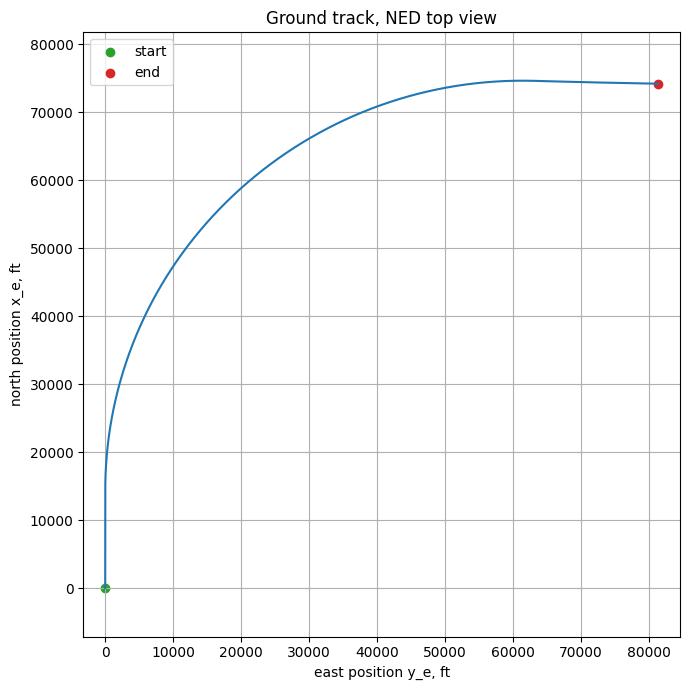

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(log["y_e"], log["x_e"], color="tab:blue")
ax.scatter(log["y_e"][0], log["x_e"][0], color="tab:green", label="start")
ax.scatter(log["y_e"][-1], log["x_e"][-1], color="tab:red", label="end")
ax.set_xlabel("east position y_e, ft")
ax.set_ylabel("north position x_e, ft")
ax.set_title("Ground track, NED top view")
ax.axis("equal")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


## 9. Quantitative checks


In [9]:
turn_active = log["t"] >= (TURN_START_SEC + 10.0)
last_20s = log["t"] >= max(log["t"][-1] - 20.0, 0.0)

metrics = {
    "final_heading_error_deg": float(log["psi_error"][-1]),
    "max_abs_heading_error_after_30s_deg": float(np.max(np.abs(log["psi_error"][turn_active]))),
    "max_abs_bank_deg": float(np.max(np.abs(log["phi"]))),
    "max_abs_sideslip_deg": float(np.max(np.abs(log["beta"]))),
    "max_abs_altitude_error_ft": float(np.max(np.abs(log["altitude"] - ALTITUDE_FT))),
    "final_altitude_error_ft": float(log["altitude"][-1] - ALTITUDE_FT),
    "max_abs_altitude_error_last_20s_ft": float(np.max(np.abs(log["altitude"][last_20s] - ALTITUDE_FT))),
    "mean_abs_altitude_error_last_20s_ft": float(np.mean(np.abs(log["altitude"][last_20s] - ALTITUDE_FT))),
    "max_abs_speed_error_ft_s": float(np.max(np.abs(log["speed"] - AIRSPEED_FT_S))),
    "final_speed_error_ft_s": float(log["speed"][-1] - AIRSPEED_FT_S),
    "final_throttle": float(log["throttle"][-1]),
    "max_abs_throttle_delta": float(np.max(np.abs(log["throttle"] - throttle_trim))),
    "max_abs_aileron_deg": float(np.max(np.abs(log["delta_a"]))),
    "max_abs_rudder_deg": float(np.max(np.abs(log["delta_r"]))),
    "rms_ihdp_aileron_residual_deg": float(np.sqrt(np.mean(log["ihdp_aileron"] ** 2))),
    "rms_ihdp_rudder_residual_deg": float(np.sqrt(np.mean(log["ihdp_rudder"] ** 2))),
}

print("=== B-737 MIMO IHDP lateral turn metrics ===")
for name, value in metrics.items():
    print(f"{name:42s}: {value: .6f}")


=== B-737 MIMO IHDP lateral turn metrics ===
final_heading_error_deg                   : -0.982038
max_abs_heading_error_after_30s_deg       :  1.551638
max_abs_bank_deg                          :  12.789653
max_abs_sideslip_deg                      :  0.113342
max_abs_altitude_error_ft                 :  2.715003
final_altitude_error_ft                   :  0.045406
max_abs_altitude_error_last_20s_ft        :  1.473167
mean_abs_altitude_error_last_20s_ft       :  0.562585
max_abs_speed_error_ft_s                  :  0.849737
final_speed_error_ft_s                    : -0.339101
final_throttle                            :  0.479231
max_abs_throttle_delta                    :  0.007514
max_abs_aileron_deg                       :  3.419351
max_abs_rudder_deg                        :  0.212492
rms_ihdp_aileron_residual_deg             :  0.331375
rms_ihdp_rudder_residual_deg              :  0.134840


## 10. Notes

* This notebook uses **one** MIMO `IHDPAgent` for the lateral channel. It is not four SISO agents.
* The actor output dimension is two: `[d_aileron_residual, d_rudder_residual]`.
* The commanded heading is held for the first 20 seconds, then the 90 deg turn is generated at 0.6 deg/s over 150 seconds.
* The coordinated-turn law supplies the safe reference and nominal command. IHDP learns the residual lateral correction online and is added directly to the aileron/rudder actuator commands.
* Elevator and engine throttle are held by a longitudinal altitude/airspeed stabilization law. The throttle channel now contains speed, altitude, vertical-speed, and leaky-integral altitude terms so the B-737 returns to FL200 at the end of the 200 second maneuver.
* A pure from-scratch lateral IHDP with no nominal command is possible in principle, but it needs offline pretraining or a safer exploration schedule. Direct online PE on a transport aircraft can generate excessive bank before the turn begins.
